In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 0 — Mount Google Drive  (run this first, every session)       ║
# ╚══════════════════════════════════════════════════════════════════════╝
from google.colab import drive
drive.mount('/content/drive')

# ── Project root on your Drive ───────────────────────────────────────────
# Change this if you want the project stored somewhere else in your Drive.
DRIVE_BASE = "/content/drive/MyDrive/ML_Tracker"

# ── Create the full directory tree on Drive ──────────────────────────────
import os
DIRS = [
    f"{DRIVE_BASE}/dataset/train/videos",
    f"{DRIVE_BASE}/dataset/train/annotations",
    f"{DRIVE_BASE}/dataset/val/videos",
    f"{DRIVE_BASE}/dataset/val/annotations",
    f"{DRIVE_BASE}/dataset/test/videos",
    f"{DRIVE_BASE}/dataset/test/annotations",
    f"{DRIVE_BASE}/dataset/uploaded",
    f"{DRIVE_BASE}/outputs/tracked",
    f"{DRIVE_BASE}/outputs/reports",
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

print(f"✅ Drive mounted.")
print(f"✅ Project root  : {DRIVE_BASE}")
print(f"✅ Directory tree created on your Drive:")
for d in DIRS:
    print(f"   📁 {d}/")
print()
print("👉 Upload your videos to:")
print(f"   {DRIVE_BASE}/dataset/uploaded/")
print("   Then run Cell 4 to scan and assign them to splits.")


Mounted at /content/drive
✅ Drive mounted.
✅ Project root  : /content/drive/MyDrive/ML_Tracker
✅ Directory tree created on your Drive:
   📁 /content/drive/MyDrive/ML_Tracker/dataset/train/videos/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/train/annotations/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/val/videos/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/val/annotations/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/test/videos/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/test/annotations/
   📁 /content/drive/MyDrive/ML_Tracker/dataset/uploaded/
   📁 /content/drive/MyDrive/ML_Tracker/outputs/tracked/
   📁 /content/drive/MyDrive/ML_Tracker/outputs/reports/

👉 Upload your videos to:
   /content/drive/MyDrive/ML_Tracker/dataset/uploaded/
   Then run Cell 4 to scan and assign them to splits.


# 🎯 Real-World Traditional ML Object Tracker
### Zero Neural Networks — Works on Your Custom Videos

> A complete, production-quality multi-object tracking pipeline built entirely from classical computer vision and machine learning algorithms — no deep learning required.

---

**Full pipeline:**
```
Upload Videos → (Optional) Annotate Bounding Boxes → Dataset Split
  → Grid-Search Hyperparameters (Train) → Select Best Config (Val)
  → Final Evaluation (Test) → Download Annotated Videos + Report
```

**Algorithms used (zero neural networks):**

| Component | Method | Purpose |
|---|---|---|
| Background Subtraction | MOG2 / GMG | Detect foreground objects (static camera) |
| Camera Stabilisation | Lucas-Kanade Optical Flow | Compensate for moving cameras |
| Blob Detection | Morphological operations | Extract object regions |
| State Estimation | Kalman Filter (x,y,w,h,vx,vy) | Smooth position & velocity |
| Assignment | Hungarian Algorithm | Optimal track-detection matching |
| Re-Identification | HSV Color Histogram | Recover lost tracks after occlusion |
| Neural Detection | YOLOv8 | High-accuracy object detection (GPU-accelerated) |
| Tuning | Grid Search | Select best hyperparameters on training data |

---

## 📋 Table of Contents
1. [Install Dependencies](#cell-1)
2. [Imports & Setup](#cell-2)
3. [Core Tracker Classes](#cell-3)
4. [Upload Videos](#cell-4)
5. [Annotation Tool](#cell-5)
5c. [Auto-Generate YOLO Ground Truth](#cell-4c)
6. [Tracking Pipeline & Evaluation](#cell-6)
7. [Training: Grid Search](#cell-7)
8. [Validation: Select Best Config](#cell-8)
9. [Test: Final Evaluation](#cell-9)
10. [Results Dashboard](#cell-10)
11. [Summary Report](#cell-11)
12. [Download Outputs](#cell-12)

---

> **Quick Start:**
> 1. Run **Cell 1 → Cell 3** once to install and initialise.
> 2. Upload your MP4 videos in **Cell 4**.
> 3. Assign videos to splits in **Cell 4b**.
> 4. Run **Cell 4c** to auto-generate YOLO ground-truth annotations.
> 5. Run **Cells 6 → 12** top-to-bottom for the full experiment.


## 📦 Cell 1 — Install Dependencies

Installs all required packages. Run this cell first, every session.

In [2]:
# ── Cell 1 — Install Dependencies ────────────────────────────────────────────
!pip install filterpy scipy opencv-python-headless ipywidgets --quiet
!pip install ultralytics --quiet

# lap provides a fast Jonker-Volgenant solver (optional but speeds up large grids)
!pip install lap --quiet 2>/dev/null || echo "⚠️  lap not available — scipy Hungarian fallback will be used"

import IPython
IPython.display.clear_output()
print("✅ All dependencies installed successfully.")
print("✅ Ultralytics (YOLOv8) installed successfully.")

✅ All dependencies installed successfully.
✅ Ultralytics (YOLOv8) installed successfully.


## 📚 Cell 2 — Imports & Directory Setup

Imports all libraries and creates the required folder structure for dataset organisation and outputs.

In [3]:
# ── Cell 2 — Imports & Directory Setup ───────────────────────────────────────
import cv2
import numpy as np
import math
import os
import json
import time
import shutil
import csv
import glob
import itertools
import copy
import warnings

from collections import OrderedDict, deque
from scipy.spatial import distance as dist
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# Suppress minor OpenCV / numpy warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ── Set global random seed ────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Load YOLO model ───────────────────────────────────────────────────────────
print("⏳ Loading YOLOv8n model...")
yolo_model = YOLO("yolov8n.pt")  # downloads automatically on first run
print("✅ YOLOv8n loaded.")

print("✅ Imports complete. (DRIVE_BASE set in Cell 0)")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Loading YOLOv8n model...
✅ YOLOv8n loaded.
✅ Imports complete. (DRIVE_BASE set in Cell 0)


## 🧩 Cell 3 — Core Tracker Classes

All classical ML components are defined here. Run once; used by every downstream cell.

| Class | What it does |
|---|---|
| `MotionCompensator` | Stabilises moving-camera footage via Lucas-Kanade optical flow |
| `BackgroundSubtractor` | Detects foreground blobs using MOG2 / GMG / LSBP |
| `KalmanTracker` | 6-state constant-velocity Kalman filter per object |
| `MultiObjectTracker` | Combines Hungarian assignment + HSV re-ID for robust MOT |


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  A. CAMERA MOTION COMPENSATOR
# ═══════════════════════════════════════════════════════════════════════════════
class MotionCompensator:
    def __init__(self, enabled: bool = True):
        self.enabled   = enabled
        self.prev_gray = None
        self.lk_params = dict(
            winSize  = (21, 21),
            maxLevel = 3,
            criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 20, 0.01),
        )
        self.feat_params = dict(
            maxCorners   = 200,
            qualityLevel = 0.01,
            minDistance  = 10,
            blockSize    = 5,
        )

    def compensate(self, frame: np.ndarray):
        if not self.enabled:
            return frame, np.eye(2, 3, dtype=np.float32)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        H    = np.eye(2, 3, dtype=np.float32)

        if self.prev_gray is not None:
            pts0 = cv2.goodFeaturesToTrack(self.prev_gray, mask=None, **self.feat_params)
            if pts0 is not None and len(pts0) >= 6:
                pts1, status, _ = cv2.calcOpticalFlowPyrLK(
                    self.prev_gray, gray, pts0, None, **self.lk_params
                )
                good0 = pts0[status.ravel() == 1]
                good1 = pts1[status.ravel() == 1]
                if len(good0) >= 6:
                    H, _ = cv2.estimateAffinePartial2D(
                        good0, good1, method=cv2.RANSAC, ransacReprojThreshold=3
                    )
                    if H is None:
                        H = np.eye(2, 3, dtype=np.float32)
                    else:
                        frame = cv2.warpAffine(
                            frame, H, (frame.shape[1], frame.shape[0]),
                            flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REPLICATE,
                        )

        self.prev_gray = gray
        return frame, H


# ═══════════════════════════════════════════════════════════════════════════════
#  B. BACKGROUND SUBTRACTOR  (MOG2 / GMG)
# ═══════════════════════════════════════════════════════════════════════════════
class BackgroundSubtractor:
    def __init__(
        self,
        method: str        = "MOG2",
        var_threshold: int = 40,
        min_area: int      = 500,
        morph_kernel: int  = 5,
    ):
        self.min_area = min_area
        self.kernel   = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel)
        )

        if method == "MOG2":
            self.bg = cv2.createBackgroundSubtractorMOG2(
                history=300, varThreshold=var_threshold, detectShadows=True
            )
        elif method == "GMG":
            self.bg = cv2.bgsegm.createBackgroundSubtractorGMG(
                initializationFrames=60
            )
        else:
            raise ValueError(
                f"Unknown background method: '{method}'. "
                "Choose from: 'MOG2', 'GMG'."
            )

    def get_mask(self, frame: np.ndarray) -> np.ndarray:
        mask = self.bg.apply(frame)
        mask[mask == 127] = 0
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  self.kernel, iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, self.kernel, iterations=3)
        return mask

    def detect(self, mask: np.ndarray) -> list:
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        detections = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if area < self.min_area:
                continue
            x, y, w, h = cv2.boundingRect(contour)
            detections.append({
                "bbox":     (x, y, w, h),
                "centroid": (x + w // 2, y + h // 2),
                "area":     int(area),
            })
        return detections


# ═══════════════════════════════════════════════════════════════════════════════
#  C. YOLO DETECTOR
#     Wraps YOLOv8 inference into the same dict format as BackgroundSubtractor
#     so the rest of the pipeline (Kalman, Hungarian, Re-ID) is unchanged.
#
#     conf_threshold : minimum YOLO confidence to accept a detection
#     min_area       : minimum bbox area in px² (filters tiny false positives)
#     allowed_classes: list of YOLO class IDs to keep, None = keep all
#                      e.g. [0] = person only, [0,2,7] = person+car+truck
# ═══════════════════════════════════════════════════════════════════════════════
class YOLODetector:
    def __init__(
        self,
        model,
        conf_threshold: float = 0.4,
        min_area: int         = 500,
        allowed_classes: list = None,
    ):
        self.model           = model
        self.conf_threshold  = conf_threshold
        self.min_area        = min_area
        self.allowed_classes = allowed_classes  # None = all classes

    def detect(self, frame: np.ndarray) -> list:
        results    = self.model(frame, verbose=False, conf=self.conf_threshold)[0]
        detections = []
        for box in results.boxes:
            # class filter
            if self.allowed_classes is not None:
                cls_id = int(box.cls[0])
                if cls_id not in self.allowed_classes:
                    continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x, y, w, h      = x1, y1, x2 - x1, y2 - y1
            area             = w * h

            if area < self.min_area:
                continue

            detections.append({
                "bbox":     (x, y, w, h),
                "centroid": (x + w // 2, y + h // 2),
                "area":     area,
            })
        return detections


# ═══════════════════════════════════════════════════════════════════════════════
#  D. KALMAN TRACKER (per object)
# ═══════════════════════════════════════════════════════════════════════════════
class KalmanTracker:
    _id_counter: int = 0

    def __init__(self, bbox: tuple, kf_r: float = 10.0, kf_q: float = 1.0):
        KalmanTracker._id_counter += 1
        self.id         = KalmanTracker._id_counter
        self.age        = 0
        self.hits       = 0
        self.no_det     = 0
        self.trajectory = deque(maxlen=80)
        self.color      = None
        self.hist       = None

        kf = KalmanFilter(dim_x=6, dim_z=4)
        kf.F = np.array([
            [1, 0, 0, 0, 1, 0],
            [0, 1, 0, 0, 0, 1],
            [0, 0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1],
        ], dtype=float)
        kf.H = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0, 0],
        ], dtype=float)
        kf.P     *= 500
        kf.R     *= kf_r
        kf.Q[4:, 4:] *= kf_q

        x, y, w, h = bbox
        kf.x = np.array([[x], [y], [w], [h], [0.0], [0.0]])
        self.kf = kf

    def predict(self) -> tuple:
        self.kf.predict()
        self.age += 1
        px, py = int(self.kf.x[0, 0]), int(self.kf.x[1, 0])
        self.trajectory.append((px, py))
        return px, py

    def update(self, bbox: tuple) -> None:
        x, y, w, h = bbox
        self.kf.update(np.array([[x], [y], [w], [h]]))
        self.hits  += 1
        self.no_det = 0

    def get_state(self) -> tuple:
        x, y, w, h = [int(self.kf.x[i, 0]) for i in range(4)]
        vx = float(self.kf.x[4, 0])
        vy = float(self.kf.x[5, 0])
        speed = float(np.hypot(vx, vy))
        return x, y, w, h, vx, vy, speed


# ═══════════════════════════════════════════════════════════════════════════════
#  E. COLOR HISTOGRAM RE-IDENTIFICATION
# ═══════════════════════════════════════════════════════════════════════════════
def compute_hist(frame: np.ndarray, bbox: tuple):
    x, y, w, h = bbox
    x, y = max(0, x), max(0, y)
    roi  = frame[y : y + h, x : x + w]
    if roi.size == 0:
        return None
    hsv  = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1], None, [18, 16], [0, 180, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


def hist_similarity(h1, h2) -> float:
    if h1 is None or h2 is None:
        return 0.0
    return float(cv2.compareHist(
        h1.reshape(-1, 1).astype(np.float32),
        h2.reshape(-1, 1).astype(np.float32),
        cv2.HISTCMP_CORREL,
    ))


# ═══════════════════════════════════════════════════════════════════════════════
#  F. MULTI-OBJECT TRACKER
# ═══════════════════════════════════════════════════════════════════════════════
PALETTE = [
    (255, 80,  80),  (80,  255, 80),  (80,  80,  255), (255, 220, 0),
    (255, 80,  255), (0,   220, 255), (255, 140, 0),   (140, 0,   255),
    (0,   255, 160), (200, 200, 200), (255, 160, 80),  (80,  255, 200),
]


class MultiObjectTracker:
    def __init__(
        self,
        max_disappeared: int   = 25,
        max_distance: float    = 120.0,
        reid_threshold: float  = 0.60,
        kf_r: float            = 10.0,
        kf_q: float            = 1.0,
    ):
        self.max_disappeared = max_disappeared
        self.max_distance    = max_distance
        self.reid_threshold  = reid_threshold
        self.kf_r            = kf_r
        self.kf_q            = kf_q
        self.trackers        = OrderedDict()
        self.dormant         = []
        self.id_counter      = 0

    def _register(self, det: dict, frame: np.ndarray) -> KalmanTracker:
        kt        = KalmanTracker(det["bbox"], self.kf_r, self.kf_q)
        kt.color  = PALETTE[self.id_counter % len(PALETTE)]
        kt.hist   = compute_hist(frame, det["bbox"])
        self.trackers[kt.id] = kt
        self.id_counter     += 1
        return kt

    def update(self, detections: list, frame: np.ndarray) -> OrderedDict:
        for kt in list(self.trackers.values()):
            kt.predict()

        if not detections:
            for oid, kt in list(self.trackers.items()):
                kt.no_det += 1
                if kt.no_det > self.max_disappeared:
                    self.dormant.append(kt)
                    del self.trackers[oid]
            return self.trackers

        if not self.trackers:
            for det in detections:
                self._register(det, frame)
            return self.trackers

        track_ids  = list(self.trackers.keys())
        track_kts  = [self.trackers[i] for i in track_ids]
        det_ctrs   = [d["centroid"] for d in detections]
        pred_ctrs  = [(int(kt.kf.x[0, 0]), int(kt.kf.x[1, 0])) for kt in track_kts]

        spatial    = dist.cdist(np.array(pred_ctrs), np.array(det_ctrs))
        appearance = np.ones_like(spatial)
        for ti, kt in enumerate(track_kts):
            if kt.hist is None:
                continue
            for di, det in enumerate(detections):
                h2 = compute_hist(frame, det["bbox"])
                appearance[ti, di] = 1.0 - hist_similarity(kt.hist, h2)

        sp_norm = spatial / (self.max_distance + 1e-6)
        cost    = 0.70 * sp_norm + 0.30 * appearance

        row_ind, col_ind = linear_sum_assignment(cost)
        matched_t, matched_d = set(), set()

        for r, c in zip(row_ind, col_ind):
            if spatial[r, c] > self.max_distance:
                continue
            oid = track_ids[r]
            self.trackers[oid].update(detections[c]["bbox"])
            self.trackers[oid].hist = compute_hist(frame, detections[c]["bbox"])
            matched_t.add(r)
            matched_d.add(c)

        for r, oid in enumerate(track_ids):
            if r not in matched_t:
                self.trackers[oid].no_det += 1
                if self.trackers[oid].no_det > self.max_disappeared:
                    self.dormant.append(self.trackers[oid])
                    del self.trackers[oid]

        for c, det in enumerate(detections):
            if c in matched_d:
                continue
            h_new   = compute_hist(frame, det["bbox"])
            best_sim, best_kt = -1.0, None
            for dkt in self.dormant:
                sim = hist_similarity(dkt.hist, h_new)
                if sim > best_sim:
                    best_sim, best_kt = sim, dkt

            if best_sim >= self.reid_threshold and best_kt is not None:
                best_kt.update(det["bbox"])
                best_kt.no_det = 0
                best_kt.hist   = h_new
                self.trackers[best_kt.id] = best_kt
                self.dormant.remove(best_kt)
            else:
                self._register(det, frame)

        self.dormant = self.dormant[-30:]
        return self.trackers


print("✅ All tracker classes defined:")
print("   MotionCompensator    — Lucas-Kanade camera stabilisation")
print("   BackgroundSubtractor — MOG2 / GMG + morphological cleanup")
print("   YOLODetector         — YOLOv8 inference, same output format as BGSub")
print("   KalmanTracker        — 6-state constant-velocity Kalman filter")
print("   MultiObjectTracker   — Hungarian assignment + HSV Re-ID")

✅ All tracker classes defined:
   MotionCompensator    — Lucas-Kanade camera stabilisation
   BackgroundSubtractor — MOG2 / GMG + morphological cleanup
   YOLODetector         — YOLOv8 inference, same output format as BGSub
   KalmanTracker        — 6-state constant-velocity Kalman filter
   MultiObjectTracker   — Hungarian assignment + HSV Re-ID


## 📤 Cell 4 — Upload Your Custom Videos

Upload your video files and assign each to a dataset split.

**Requirements:**
- At least **1 training video**, **1 validation video**, and **1 test video**
- Supported formats: `.mp4`, `.avi`, `.mov`, `.mkv`
- Any resolution or frame rate is supported


In [5]:
# ── Cell 4 — Scan Drive upload folder for videos ────────────────────────────
# Place your video files in:
#   MyDrive/ML_Tracker/dataset/uploaded/
# Then run this cell to detect them automatically.

SUPPORTED_EXT = {'.mp4', '.avi', '.mov', '.mkv'}

upload_dir = f"{DRIVE_BASE}/dataset/uploaded"
all_files  = os.listdir(upload_dir)
uploaded_names = [
    f for f in all_files
    if os.path.splitext(f)[1].lower() in SUPPORTED_EXT
]

if not uploaded_names:
    print(f"⚠️  No video files found in:")
    print(f"   {upload_dir}")
    print("   Supported formats: .mp4  .avi  .mov  .mkv")
    print("   Upload your videos there, then re-run this cell.")
else:
    print(f"✅ Found {len(uploaded_names)} video(s) in {upload_dir}:")
    for fname in uploaded_names:
        fpath   = os.path.join(upload_dir, fname)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"   ✓  {fname}  ({size_mb:.2f} MB)")
    print()
    print("   → Proceed to Cell 4b to assign each video to a split.")


⚠️  No video files found in:
   /content/drive/MyDrive/ML_Tracker/dataset/uploaded
   Supported formats: .mp4  .avi  .mov  .mkv
   Upload your videos there, then re-run this cell.


### Cell 4b — Assign Videos to Train / Val / Test Splits

Edit `VIDEO_SPLITS` below to control which video goes to which split. If left empty, an automatic assignment is applied.

In [8]:
# ── EDIT THIS DICTIONARY ──────────────────────────────────────────────────────
# Map each uploaded filename → 'train', 'val', or 'test'
#
# Strategy: grouped by video TYPE so every split has diverse content.
# Moving-camera videos are spread across splits so the grid search
# sees them during training, not just at test time.

VIDEO_SPLITS = {
    # ── TRAIN ──────────────────────────────────────────────────────────
    "DVD logo.mp4"               : "train",   # static, single object
    "Traffic IP Camera video.mp4": "train",   # static cam, large vehicles
    "Aim Lab1.mp4"               : "train",   # game screen / dynamic BG
    "Top View Pedestrian.mp4"    : "train",   # overhead static
    "Golden Retriever.mp4"       : "train",   # moving camera (handheld)
    "Store cam.mp4"              : "train",   # surveillance

    # ── VAL ────────────────────────────────────────────────────────────
    "Aim Lab2.mp4"               : "val",     # game screen variant
    "football_juggling.mp4"      : "val",     # moving camera + tiny ball

    # ── TEST ───────────────────────────────────────────────────────────
    "puppy.mp4"                  : "test",    # moving camera + sparse ann
    "solo_dance_nsfw.mp4"        : "test",    # static cam, sparse ann
}

VIDEO_MOVING_CAMERA = {
    "DVD logo.mp4"               : False,
    "Traffic IP Camera video.mp4": False,
    "Aim Lab1.mp4"               : False,
    "Aim Lab2.mp4"               : False,
    "Top View Pedestrian.mp4"    : False,
    "Store cam.mp4"              : False,
    "Golden Retriever.mp4"       : True,   # handheld
    "football_juggling.mp4"      : True,   # handheld
    "puppy.mp4"                  : True,   # handheld
    "solo_dance_nsfw.mp4"        : False,
}

# ── Copy files into the correct split directories ─────────────────────────────
SPLIT_VIDEOS = {"train": [], "val": [], "test": []}

for fname, split in VIDEO_SPLITS.items():
    if split not in SPLIT_VIDEOS:
        print(f"   ⚠️  Invalid split '{split}' for {fname} — must be train/val/test")
        continue
    src  = f"{DRIVE_BASE}/dataset/uploaded/{fname}"
    dest = f"{DRIVE_BASE}/dataset/{split}/videos/{fname}"
    if os.path.exists(src):
        shutil.copy(src, dest)
        SPLIT_VIDEOS[split].append(fname)
        cam_flag = "📷 moving" if VIDEO_MOVING_CAMERA.get(fname, False) else "🎥 static"
        print(f"   [{split:5s}]  {fname}  ({cam_flag})")
    else:
        print(f"   ⚠️  File not found: {src}  — check the filename matches exactly")

# ── Summary ───────────────────────────────────────────────────────────────────
print()
for split, vids in SPLIT_VIDEOS.items():
    status = "✅" if vids else "⚠️ "
    print(f"   {status} {split:5s}: {len(vids)} video(s)  {vids}")

moving_count = sum(1 for v in VIDEO_MOVING_CAMERA.values() if v)
print(f"\n   📷 Moving-camera videos : {moving_count}")
print(f"   🎥 Static-camera videos : {len(VIDEO_MOVING_CAMERA) - moving_count}")

if not SPLIT_VIDEOS["train"]:
    print("\n⚠️  WARNING: No training videos — grid search will be skipped.")
if not SPLIT_VIDEOS["val"]:
    print("⚠️  WARNING: No validation videos — best config will default to best training config.")
if not SPLIT_VIDEOS["test"]:
    print("⚠️  WARNING: No test videos — final evaluation will be skipped.")

   [train]  DVD logo.mp4  (🎥 static)
   [train]  Traffic IP Camera video.mp4  (🎥 static)
   [train]  Aim Lab1.mp4  (🎥 static)
   [train]  Top View Pedestrian.mp4  (🎥 static)
   [train]  Golden Retriever.mp4  (📷 moving)
   [train]  Store cam.mp4  (🎥 static)
   [val  ]  Aim Lab2.mp4  (🎥 static)
   [val  ]  football_juggling.mp4  (📷 moving)
   [test ]  puppy.mp4  (📷 moving)
   [test ]  solo_dance_nsfw.mp4  (🎥 static)

   ✅ train: 6 video(s)  ['DVD logo.mp4', 'Traffic IP Camera video.mp4', 'Aim Lab1.mp4', 'Top View Pedestrian.mp4', 'Golden Retriever.mp4', 'Store cam.mp4']
   ✅ val  : 2 video(s)  ['Aim Lab2.mp4', 'football_juggling.mp4']
   ✅ test : 2 video(s)  ['puppy.mp4', 'solo_dance_nsfw.mp4']

   📷 Moving-camera videos : 3
   🎥 Static-camera videos : 7


## 🤖 Cell 4c — Auto-Generate Ground-Truth Annotations with YOLO

This cell runs YOLO on **every video in every split** and saves one annotation CSV per video.
These CSVs become the **ground truth** that the grid search is scored against — so all methods
(MOG2, GMG, YOLO) are evaluated on the same YOLO-style detections.

**This must be run before Cell 7.** Re-run it any time you change `VIDEO_CLASS_FILTER` below.

| Video | Classes kept | Why |
|---|---|---|
| `puppy.mp4` | 16 (dog) | Only want the dog, not people/furniture |
| `solo_dance_nsfw.mp4` | 0 (person) | Only want the dancer |
| All others | None (all classes) | General objects — keep everything |

In [9]:
# ── Cell 4c — Auto-Generate YOLO Ground-Truth Annotations ───────────────────
#
# YOLO conf and class filter are FIXED here (not searched) so that ground truth
# is stable and consistent across all grid-search combos.
#
# Edit VIDEO_CLASS_FILTER to control which COCO classes count as ground truth
# for each video.  None = keep all detected classes.
#
# COCO class IDs (common ones):
#   0  = person       15 = bird        16 = cat
#   2  = car          16 = dog (note: dog is 16, cat is 15)
#   7  = truck        17 = horse
#
# Correct COCO class IDs:
#   0  = person
#   1  = bicycle
#   2  = car
#  14  = bird
#  15  = cat
#  16  = dog
# ─────────────────────────────────────────────────────────────────────────────

YOLO_GT_CONF = 0.4          # fixed confidence for ground-truth generation
YOLO_GT_MIN_AREA = 500      # minimum bbox area in px² to include

# Per-video class filter — None means keep all detected classes
VIDEO_CLASS_FILTER = {
    "puppy.mp4"           : [16],   # dog only
    "solo_dance_nsfw.mp4" : [0],    # person only
    # All other videos default to None (keep all classes)
}

def generate_yolo_annotations(video_path, allowed_classes=None):
    """
    Run YOLO frame-by-frame on a video and return annotations dict.
    Returns: {frame_id: [{"object_id": int, "bbox": (x,y,w,h), "centroid": (cx,cy)}, ...]}
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"      ❌ Could not open: {video_path}")
        return {}

    annotations = {}
    frame_idx   = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results    = yolo_model(frame, verbose=False, conf=YOLO_GT_CONF)[0]
        frame_dets = []
        obj_id     = 1

        for box in results.boxes:
            cls_id = int(box.cls[0])
            if allowed_classes is not None and cls_id not in allowed_classes:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x, y, w, h      = x1, y1, x2 - x1, y2 - y1
            area             = w * h

            if area < YOLO_GT_MIN_AREA:
                continue

            frame_dets.append({
                "object_id": obj_id,
                "bbox"     : (x, y, w, h),
                "centroid" : (x + w // 2, y + h // 2),
            })
            obj_id += 1

        if frame_dets:
            annotations[frame_idx] = frame_dets

        frame_idx += 1

    cap.release()
    return annotations


# ── Run on all splits ─────────────────────────────────────────────────────────
import re as _re

print("=" * 65)
print(f"{'  CELL 4c — YOLO Ground-Truth Annotation':^65}")
print("=" * 65)
print(f"   YOLO conf      : {YOLO_GT_CONF}")
print(f"   Min area       : {YOLO_GT_MIN_AREA} px²")
print()

total_saved = 0

for split in ["train", "val", "test"]:
    vids = SPLIT_VIDEOS.get(split, [])
    if not vids:
        print(f"   [{split:5s}]  (no videos)")
        continue

    for vname in vids:
        vpath      = f"{DRIVE_BASE}/dataset/{split}/videos/{vname}"
        base       = _re.sub(r'\s*\(\d+\)\s*$', '', os.path.splitext(vname)[0]).strip()
        csv_path   = f"{DRIVE_BASE}/dataset/{split}/annotations/{base}.csv"
        classes    = VIDEO_CLASS_FILTER.get(vname, None)
        class_str  = str(classes) if classes is not None else "all classes"

        print(f"   [{split:5s}]  {vname}  (filter: {class_str})")

        if not os.path.exists(vpath):
            print(f"            ⚠️  Video not found — skipping")
            continue

        anns = generate_yolo_annotations(vpath, allowed_classes=classes)

        if not anns:
            print(f"            ⚠️  No detections — CSV not saved")
            continue

        # Save CSV — always overwrite so GT stays YOLO-based
        with open(csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["frame_id", "object_id", "x", "y", "w", "h"])
            for fid in sorted(anns):
                for obj in anns[fid]:
                    x, y, w, h = obj["bbox"]
                    writer.writerow([fid, obj["object_id"], x, y, w, h])

        n_frames = len(anns)
        n_boxes  = sum(len(v) for v in anns.values())
        print(f"            ✅ {n_frames} annotated frames, {n_boxes} total boxes → {csv_path}")
        total_saved += 1

print()
print(f"✅ Cell 4c complete — {total_saved} annotation CSV(s) saved.")
print("   → Proceed to Cell 6 → Cell 7 for grid search.")


              CELL 4c — YOLO Ground-Truth Annotation             
   YOLO conf      : 0.4
   Min area       : 500 px²

   [train]  DVD logo.mp4  (filter: all classes)
            ⚠️  No detections — CSV not saved
   [train]  Traffic IP Camera video.mp4  (filter: all classes)
            ✅ 750 annotated frames, 2457 total boxes → /content/drive/MyDrive/ML_Tracker/dataset/train/annotations/Traffic IP Camera video.csv
   [train]  Aim Lab1.mp4  (filter: all classes)
            ✅ 50 annotated frames, 50 total boxes → /content/drive/MyDrive/ML_Tracker/dataset/train/annotations/Aim Lab1.csv
   [train]  Top View Pedestrian.mp4  (filter: all classes)
            ✅ 607 annotated frames, 2163 total boxes → /content/drive/MyDrive/ML_Tracker/dataset/train/annotations/Top View Pedestrian.csv
   [train]  Golden Retriever.mp4  (filter: all classes)
            ✅ 523 annotated frames, 1590 total boxes → /content/drive/MyDrive/ML_Tracker/dataset/train/annotations/Golden Retriever.csv
   [train]  Store 

## 🏷️ Cell 5 — Annotation Tool

Annotations are optional but strongly recommended for meaningful metrics.

| Option | When to use |
|---|---|
| **Cell 5a** — Load existing CSVs | You already have annotation files |
| **Cell 5b** — Interactive labeler | You want to draw bounding boxes frame-by-frame |
| **Skip entirely** | Use auto-detection only (no GT metrics) |

**CSV format (one file per video, matching the video filename):**
```
frame_id, object_id, x, y, w, h
0,        1,         120, 80, 50, 90
0,        2,         300, 150, 60, 100
1,        1,         125, 82, 50, 90
```


In [10]:
import re, glob

# ── Helper: Load annotation CSV ───────────────────────────────────────────────
def load_annotations_csv(csv_path: str) -> dict:
    annotations = {}
    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            fid = int(row["frame_id"])
            x, y, w, h = int(row["x"]), int(row["y"]), int(row["w"]), int(row["h"])
            obj = {
                "object_id": int(row["object_id"]),
                "bbox":      (x, y, w, h),
                "centroid":  (x + w // 2, y + h // 2),
            }
            annotations.setdefault(fid, []).append(obj)
    return annotations


def save_annotations_csv(annotations: dict, csv_path: str) -> None:
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame_id", "object_id", "x", "y", "w", "h"])
        for fid in sorted(annotations):
            for obj in annotations[fid]:
                x, y, w, h = obj["bbox"]
                writer.writerow([fid, obj["object_id"], x, y, w, h])


def load_gt_for_video(split: str, video_name: str) -> dict:
    base    = os.path.splitext(video_name)[0]
    csvpath = f"{DRIVE_BASE}/dataset/{split}/annotations/{base}.csv"
    if not os.path.exists(csvpath):
        # Also try the clean name without (N) suffix
        clean = re.sub(r'\s*\(\d+\)\s*$', '', base).strip()
        csvpath = f"{DRIVE_BASE}/dataset/{split}/annotations/{clean}.csv"
        if not os.path.exists(csvpath):
            return {}
    return load_annotations_csv(csvpath)


def clean_name(filename: str) -> str:
    """Strip extension and any trailing (N) suffix, lowercase for comparison."""
    base = os.path.splitext(filename)[0]
    return re.sub(r'\s*\(\d+\)\s*$', '', base).strip().lower()


# ── Cell 5a: Upload existing annotation CSVs ─────────────────────────────────

# ── Cell 5a: Copy annotation CSVs from Drive ────────────────────────────────
# Place annotation CSV files (named to match your video files) in:
#   MyDrive/ML_Tracker/dataset/uploaded/
# They will be matched to the correct split folder automatically.

ann_dir = f"{DRIVE_BASE}/dataset/uploaded"
csv_files = [f for f in os.listdir(ann_dir) if f.lower().endswith('.csv')]

if not csv_files:
    print("   (No CSV files found in uploaded/ — continuing without ground-truth annotations)")
else:
    for fname in csv_files:
        csv_clean = clean_name(fname)
        placed    = False
        for split in ['train', 'val', 'test']:
            for vname in SPLIT_VIDEOS[split]:
                vid_clean = clean_name(vname)
                if vid_clean == csv_clean:
                    clean_base = re.sub(r'\s*\(\d+\)\s*$', '',
                                        os.path.splitext(vname)[0]).strip()
                    dest = f"{DRIVE_BASE}/dataset/{split}/annotations/{clean_base}.csv"
                    shutil.copy(os.path.join(ann_dir, fname), dest)
                    print(f"   ✅  [{split}]  {fname}  →  {clean_base}.csv")
                    placed = True
        if not placed:
            print(f"   ⚠️   Could not match '{fname}'")
            print(f"        CSV clean name : '{csv_clean}'")
            print(f"        Video names    : {[clean_name(v) for vlist in SPLIT_VIDEOS.values() for v in vlist]}")


   (No CSV files found in uploaded/ — continuing without ground-truth annotations)


In [ ]:
# ── Cell 5b: Interactive Frame Labeler ───────────────────────────────────────
# Set LABEL_VIDEO to the filename you want to annotate.
# Leave it empty ('') to skip this step.

LABEL_VIDEO   = ""          # e.g. "parking.mp4"
LABEL_SPLIT   = "train"     # "train", "val", or "test"
LABEL_EVERY_N = 5           # annotate every Nth frame; intermediate frames
                             # are filled in by linear interpolation

if not LABEL_VIDEO:
    print("LABEL_VIDEO is empty — skipping interactive labeler.")
    print("Set LABEL_VIDEO = 'your_video.mp4' to enable it.")
else:
    vpath    = f"{DRIVE_BASE}/dataset/{LABEL_SPLIT}/videos/{LABEL_VIDEO}"
    ann_path = f"{DRIVE_BASE}/dataset/{LABEL_SPLIT}/annotations/{os.path.splitext(LABEL_VIDEO)[0]}.csv"

    if not os.path.exists(vpath):
        print(f"❌ Video not found: {vpath}")
    else:
        cap     = cv2.VideoCapture(vpath)
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        all_anns: dict = {}

        frame_indices = list(range(0, total_f, LABEL_EVERY_N))
        print(f"Labeling '{LABEL_VIDEO}': {len(frame_indices)} keyframes")
        print("Instructions: click-drag to draw bounding boxes, then close the figure to advance.")

        for fi in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ret, frame = cap.read()
            if not ret:
                break

            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            coords = {"x0": None, "y0": None, "drawing": False, "rects": []}
            fig, ax = plt.subplots(figsize=(12, 7))
            ax.imshow(rgb)
            ax.set_title(
                f"Frame {fi}/{total_f - 1}  —  Click-drag to draw bounding boxes\n"
                "Close this figure when done with this frame.",
                fontsize=11
            )

            def on_press(event):
                if event.inaxes != ax:
                    return
                coords["x0"], coords["y0"] = event.xdata, event.ydata
                coords["drawing"] = True

            def on_release(event):
                if not coords["drawing"] or event.inaxes != ax:
                    return
                x0, y0 = coords["x0"], coords["y0"]
                x1, y1 = event.xdata, event.ydata
                x, y = int(min(x0, x1)), int(min(y0, y1))
                w, h = int(abs(x1 - x0)), int(abs(y1 - y0))
                if w > 5 and h > 5:
                    coords["rects"].append((x, y, w, h))
                    rect = plt.Rectangle(
                        (x, y), w, h,
                        linewidth=2, edgecolor="lime", facecolor="none"
                    )
                    ax.add_patch(rect)
                    ax.text(x, y - 5, f"obj{len(coords['rects'])}",
                            color="lime", fontsize=9, fontweight="bold")
                    fig.canvas.draw()
                coords["drawing"] = False

            fig.canvas.mpl_connect("button_press_event",   on_press)
            fig.canvas.mpl_connect("button_release_event", on_release)
            plt.tight_layout()
            plt.show()

            all_anns[fi] = [
                {
                    "object_id": bid,
                    "bbox":      (x, y, w, h),
                    "centroid":  (x + w // 2, y + h // 2),
                }
                for bid, (x, y, w, h) in enumerate(coords["rects"], start=1)
            ]

        cap.release()

        # ── Linear interpolation between labelled keyframes ───────────────
        sorted_keys = sorted(all_anns.keys())
        for i in range(len(sorted_keys) - 1):
            f0, f1   = sorted_keys[i], sorted_keys[i + 1]
            objs0, objs1 = all_anns[f0], all_anns[f1]
            n_common = min(len(objs0), len(objs1))
            for fi in range(f0 + 1, f1):
                alpha = (fi - f0) / (f1 - f0)
                interp = []
                for j in range(n_common):
                    b0 = np.array(objs0[j]["bbox"])
                    b1 = np.array(objs1[j]["bbox"])
                    bi = (b0 * (1 - alpha) + b1 * alpha).astype(int)
                    cx, cy = bi[0] + bi[2] // 2, bi[1] + bi[3] // 2
                    interp.append({
                        "object_id": j + 1,
                        "bbox":      tuple(bi.tolist()),
                        "centroid":  (cx, cy),
                    })
                all_anns[fi] = interp

        save_annotations_csv(all_anns, ann_path)
        print(f"\n✅ Saved {len(all_anns)} annotated frames → {ann_path}")


LABEL_VIDEO is empty — skipping interactive labeler.
Set LABEL_VIDEO = 'your_video.mp4' to enable it.


## 🔧 Cell 6 — Tracking Pipeline & Evaluation Engine

`run_tracker_on_video()` is the core engine. It:
1. Applies camera stabilisation (optional)
2. Detects foreground blobs via background subtraction
3. Assigns detections to tracks using the Hungarian algorithm
4. Evaluates against ground-truth using centroid matching
5. Writes an annotated output video (optional)

**Metrics computed:**
- **Precision / Recall / F1** — detection accuracy
- **MAE (px)** — mean centroid localisation error
- **MOTA** — Multiple Object Tracking Accuracy (industry standard)
- **ID Switches** — how often a track's identity changes (lower is better)


In [11]:
# ── Per-video warmup override ────────────────────────────────────────────────
# GMG needs 60+ frames to initialise. YOLO needs no warmup at all.

VIDEO_WARMUP = {
    "DVD logo.mp4":                20,
    "Traffic IP Camera video.mp4": 20,
    "Aim Lab1.mp4":                20,
    "Aim Lab2.mp4":                20,
    "Top View Pedestrian.mp4":     20,
    "Store cam.mp4":               20,
    "Golden Retriever.mp4":        20,
    "football_juggling.mp4":       20,
    "puppy.mp4":                   20,
    "solo_dance_nsfw.mp4":         20,
}


def run_tracker_on_video(
    video_path: str,
    params: dict,
    output_path: str  = None,
    ground_truth: dict = None,
    warmup: int        = None,
) -> tuple:

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Could not open: {video_path}")
        return None, []

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    vname      = os.path.basename(video_path)
    bg_method  = params.get("bg_method", "MOG2")
    use_yolo   = bg_method == "YOLO"

    # ── Warmup ───────────────────────────────────────────────────────────
    if warmup is None:
        if use_yolo:
            warmup = 0                          # YOLO needs no warmup
        elif bg_method == "GMG":
            warmup = 65
        else:
            warmup = VIDEO_WARMUP.get(vname, 20)

    # ── Moving camera auto select ─────────────────────────────────────────
    if vname in VIDEO_MOVING_CAMERA:
        moving_camera = VIDEO_MOVING_CAMERA[vname]
    else:
        moving_camera = params.get("moving_camera", False)

    # ── Initialise detector ───────────────────────────────────────────────
    compensator = MotionCompensator(enabled=moving_camera)

    if use_yolo:
        # Per-video class filter: use VIDEO_CLASS_FILTER if defined, else params fallback
        _video_classes = None
        if "VIDEO_CLASS_FILTER" in globals():
            _video_classes = VIDEO_CLASS_FILTER.get(vname, params.get("allowed_classes", None))
        else:
            _video_classes = params.get("allowed_classes", None)

        detector = YOLODetector(
            model           = yolo_model,
            conf_threshold  = params.get("yolo_conf", 0.4),
            min_area        = params.get("min_area", 500),
            allowed_classes = _video_classes,
        )
    else:
        detector = BackgroundSubtractor(
            method        = bg_method,
            var_threshold = params.get("var_threshold", 40),
            min_area      = params.get("min_area", 500),
            morph_kernel  = params.get("morph_kernel", 5),
        )

    # ── Initialise tracker ────────────────────────────────────────────────
    mot = MultiObjectTracker(
        max_disappeared = params.get("max_disappeared", 25),
        max_distance    = params.get("max_distance", 120),
        reid_threshold  = params.get("reid_threshold", 0.55),
        kf_r            = params.get("kf_r", 10.0),
        kf_q            = params.get("kf_q", 1.0),
    )

    KalmanTracker._id_counter = 0

    # ── Metrics ───────────────────────────────────────────────────────────
    total_tp    = 0
    total_fp    = 0
    total_fn    = 0
    all_errors  = []
    id_switches = 0
    prev_assign = {}
    tracking_log = []
    frame_idx   = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ── Stabilise camera ─────────────────────────────────────────
        stable, _ = compensator.compensate(frame.copy())

        # ── Detect ───────────────────────────────────────────────────
        if use_yolo:
            # YOLO runs on original frame, no warmup needed
            detections = detector.detect(frame)
        else:
            mask = detector.get_mask(stable)
            if frame_idx >= warmup:
                detections = detector.detect(mask)
            else:
                detections = []

        # ── Track ────────────────────────────────────────────────────
        trackers = mot.update(detections, frame)

        pred_bboxes = []
        for kt in trackers.values():
            x, y, w, h, vx, vy, speed = kt.get_state()
            pred_bboxes.append({
                "bbox":     (x, y, w, h),
                "centroid": (x + w // 2, y + h // 2),
                "id":       kt.id,
            })

        # ── Evaluate if GT exists ─────────────────────────────────────
        gt_objs = (ground_truth or {}).get(frame_idx, [])
        if gt_objs:
            gt_ctrs   = [o["centroid"] for o in gt_objs]
            pred_ctrs = [p["centroid"] for p in pred_bboxes]
            match_thresh = params.get("match_threshold", 50)

            if pred_ctrs and gt_ctrs:
                D_eval       = dist.cdist(np.array(pred_ctrs), np.array(gt_ctrs))
                row_i, col_i = linear_sum_assignment(D_eval)
                matched_p, matched_g = set(), set()

                for r, c in zip(row_i, col_i):
                    if D_eval[r, c] <= match_thresh:
                        total_tp += 1
                        all_errors.append(float(D_eval[r, c]))
                        matched_p.add(r)
                        matched_g.add(c)
                        gt_id   = gt_objs[c].get("object_id", c)
                        pred_id = pred_bboxes[r]["id"]
                        if gt_id in prev_assign and prev_assign[gt_id] != pred_id:
                            id_switches += 1
                        prev_assign[gt_id] = pred_id

                total_fp += len(pred_ctrs) - len(matched_p)
                total_fn += len(gt_ctrs)   - len(matched_g)
            else:
                total_fp += len(pred_ctrs)
                total_fn += len(gt_ctrs)

        # ── Write output video ────────────────────────────────────────
        if writer:
            disp = frame.copy()
            for kt in trackers.values():
                x, y, w, h, vx, vy, speed = kt.get_state()
                color = kt.color
                cv2.rectangle(disp, (x, y), (x + w, y + h), color, 2)
                cv2.putText(
                    disp, f"ID:{kt.id}",
                    (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1,
                )
            writer.write(disp)

        tracking_log.append({"frame": frame_idx, "n_tracks": len(trackers)})
        frame_idx += 1

    cap.release()
    if writer:
        writer.release()

    # ── Final metrics ─────────────────────────────────────────────────
    prec = total_tp / (total_tp + total_fp + 1e-9)
    rec  = total_tp / (total_tp + total_fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    mae  = float(np.mean(all_errors)) if all_errors else float("nan")
    gt_n = total_tp + total_fn
    mota = max(0.0, 1.0 - (total_fn + total_fp + id_switches) / max(gt_n, 1))

    metrics = {
        "precision":   round(prec, 4),
        "recall":      round(rec,  4),
        "f1":          round(f1,   4),
        "mae_px":      round(mae,  2) if not math.isnan(mae) else None,
        "mota":        round(mota, 4),
        "id_switches": id_switches,
        "tp":          total_tp,
        "fp":          total_fp,
        "fn":          total_fn,
        "frames":      frame_idx,
        "detector":    bg_method,   # ← logged so dashboard can label it
    }

    return metrics, tracking_log


print("✅ run_tracker_on_video() defined and ready.")
print("   Detector : MOG2 / GMG → BackgroundSubtractor")
print("   Detector : YOLO       → YOLODetector (no warmup)")
print("   Camera   : auto per-video from VIDEO_MOVING_CAMERA")
print(f"  Moving   : {[k for k, v in VIDEO_MOVING_CAMERA.items() if v]}")

✅ run_tracker_on_video() defined and ready.
   Detector : MOG2 / GMG → BackgroundSubtractor
   Detector : YOLO       → YOLODetector (no warmup)
   Camera   : auto per-video from VIDEO_MOVING_CAMERA
  Moving   : ['Golden Retriever.mp4', 'football_juggling.mp4', 'puppy.mp4']


## 🔍 Cell 7 — Training: Hyperparameter Grid Search

Edit `PARAM_GRID` to define the search space. Every combination is evaluated on all training videos and scored by average F1.

**Tips:**
- Reduce grid size for faster iteration (fewer values per parameter)
- Set `"moving_camera": [True]` for drone / dashcam / handheld footage
- `"bg_method": ["GMG"]` may help with outdoor / changing-light scenes


In [12]:
# ── Cell 7 — Hyperparameter Grid Search ──────────────────────────────────────
# Three separate grids so no params are wasted on methods that ignore them:
#
#   MOG2 : 1 × 3 × 2 × 1 × 2 × 2 = 24 combos
#   GMG  : 1 × 1 × 2 × 1 × 2 × 2 =  8 combos  (var_threshold fixed)
#   YOLO : 1 × 1 × 2 × 1 × 2 × 2 =  8 combos  (var_threshold fixed, yolo_conf searched)
#   Total: 40 combos

PARAM_GRID_MOG2 = {
    "bg_method":       ["MOG2"],
    "var_threshold":   [30, 50, 70],        # meaningful for MOG2 only
    "min_area":        [200, 400],
    "morph_kernel":    [5],
    "max_disappeared": [20, 35],
    "max_distance":    [120, 180],
    "reid_threshold":  [0.55],
    "kf_r":            [10.0],
    "kf_q":            [1.0],
    "match_threshold": [50],
}

PARAM_GRID_GMG = {
    "bg_method":       ["GMG"],
    "var_threshold":   [40],                # GMG ignores this — one value, no waste
    "min_area":        [200, 400],
    "morph_kernel":    [5],
    "max_disappeared": [20, 35],
    "max_distance":    [120, 180],
    "reid_threshold":  [0.55],
    "kf_r":            [10.0],
    "kf_q":            [1.0],
    "match_threshold": [50],
}

PARAM_GRID_YOLO = {
    "bg_method":       ["YOLO"],
    "var_threshold":   [40],                # ignored by YOLO — placeholder only
    "yolo_conf":       [0.3, 0.5],          # confidence threshold searched here
    "min_area":        [200, 400],
    "morph_kernel":    [5],                 # ignored by YOLO — placeholder only
    "max_disappeared": [20, 35],
    "max_distance":    [120, 180],
    "reid_threshold":  [0.55],
    "kf_r":            [10.0],
    "kf_q":            [1.0],
    "match_threshold": [50],
}

def make_combos(grid):
    keys = list(grid.keys())
    return [dict(zip(keys, v)) for v in itertools.product(*grid.values())]

combos = make_combos(PARAM_GRID_MOG2) + make_combos(PARAM_GRID_GMG) + make_combos(PARAM_GRID_YOLO)

print(f"🔍 Grid search space: {len(combos):,} parameter combinations")
print(f"   MOG2 combos : {len(make_combos(PARAM_GRID_MOG2))}")
print(f"   GMG  combos : {len(make_combos(PARAM_GRID_GMG))}  (var_threshold fixed)")
print(f"   YOLO combos : {len(make_combos(PARAM_GRID_YOLO))}  (yolo_conf searched instead)")
print(f"📹 Training on : {len(SPLIT_VIDEOS.get('train', []))} video(s)")
if not SPLIT_VIDEOS.get("train"):
    print("\n⚠️  No training videos found.")
else:
    est_sec = len(combos) * len(SPLIT_VIDEOS["train"]) * 3
    print(f"⏱️  Estimated runtime: ~{est_sec // 60}–{est_sec // 30} minutes")
    print(f"⚠️  GMG combos are slower due to 65-frame warmup")
    print(f"⚠️  YOLO combos speed depends on whether Colab has a GPU")

🔍 Grid search space: 48 parameter combinations
   MOG2 combos : 24
   GMG  combos : 8  (var_threshold fixed)
   YOLO combos : 16  (yolo_conf searched instead)
📹 Training on : 6 video(s)
⏱️  Estimated runtime: ~14–28 minutes
⚠️  GMG combos are slower due to 65-frame warmup
⚠️  YOLO combos speed depends on whether Colab has a GPU


In [13]:
# ── Run grid search ───────────────────────────────────────────────────────────
import json

train_results  = []
best_train_f1  = -1.0
best_params    = None

print("=" * 65)
print(f"{'  TRAINING — Hyperparameter Grid Search':^65}")
print("=" * 65)

if not SPLIT_VIDEOS.get("train"):
    print("⚠️  Skipping grid search — no training videos available.")
else:
    t_start   = time.time()
    log_every = max(1, len(combos) // 10)

    for ci, params in enumerate(combos):

        print(
            f"🔄 Combo [{ci+1:4d}/{len(combos)}] | "
            f"bg={params['bg_method']:4s} | "
            f"var_thresh={params['var_threshold']:2} | "
            f"min_area={params['min_area']:4} | "
            f"max_dist={params['max_distance']:3} | "
            f"max_disap={params['max_disappeared']}",
            flush=True
        )

        video_f1s = []
        for vname in SPLIT_VIDEOS["train"]:
            vpath      = f"{DRIVE_BASE}/dataset/train/videos/{vname}"
            gt         = load_gt_for_video("train", vname)
            metrics, _ = run_tracker_on_video(vpath, params, ground_truth=gt)
            if metrics:
                video_f1s.append(metrics["f1"])

        avg_f1 = float(np.mean(video_f1s)) if video_f1s else 0.0
        train_results.append({"params": params, "train_f1": round(avg_f1, 4)})

        if avg_f1 > best_train_f1:
            best_train_f1 = avg_f1
            best_params   = params.copy()
            print(f"   ⭐ New best F1: {best_train_f1:.4f}", flush=True)

        if (ci + 1) % log_every == 0 or ci == len(combos) - 1:
            elapsed = time.time() - t_start
            eta     = elapsed / (ci + 1) * (len(combos) - ci - 1)
            print(
                f"   📊 [{ci+1:4d}/{len(combos)}]  "
                f"best F1={best_train_f1:.4f}  "
                f"elapsed={elapsed:.0f}s  ETA≈{eta:.0f}s",
                flush=True
            )

    print()
    print("─" * 65)
    print(f"✅ Grid search complete.  Best training F1: {best_train_f1:.4f}")
    print("\nBest hyperparameters:")
    for k, v in best_params.items():
        print(f"   {k:22s}: {v}")

# ── Save results to Drive (guarded — only if grid search actually ran) ───────
if train_results:
    with open(f"{DRIVE_BASE}/outputs/train_results.json", "w") as f:
        json.dump({
            "train_results": train_results,
            "best_params":   best_params,
            "best_train_f1": best_train_f1
        }, f)
    print("✅ Results saved to Drive.")
else:
    print("⚠️  No results to save — grid search did not run.")

               TRAINING — Hyperparameter Grid Search             
🔄 Combo [   1/48] | bg=MOG2 | var_thresh=30 | min_area= 200 | max_dist=120 | max_disap=20
   ⭐ New best F1: 0.2932
🔄 Combo [   2/48] | bg=MOG2 | var_thresh=30 | min_area= 200 | max_dist=180 | max_disap=20
   ⭐ New best F1: 0.3145
🔄 Combo [   3/48] | bg=MOG2 | var_thresh=30 | min_area= 200 | max_dist=120 | max_disap=35
🔄 Combo [   4/48] | bg=MOG2 | var_thresh=30 | min_area= 200 | max_dist=180 | max_disap=35
   📊 [   4/48]  best F1=0.3145  elapsed=492s  ETA≈5412s
🔄 Combo [   5/48] | bg=MOG2 | var_thresh=30 | min_area= 400 | max_dist=120 | max_disap=20
🔄 Combo [   6/48] | bg=MOG2 | var_thresh=30 | min_area= 400 | max_dist=180 | max_disap=20
🔄 Combo [   7/48] | bg=MOG2 | var_thresh=30 | min_area= 400 | max_dist=120 | max_disap=35
🔄 Combo [   8/48] | bg=MOG2 | var_thresh=30 | min_area= 400 | max_dist=180 | max_disap=35
   📊 [   8/48]  best F1=0.3145  elapsed=965s  ETA≈4826s
🔄 Combo [   9/48] | bg=MOG2 | var_thresh=50 | min_ar

## 📐 Cell 8 — Validation: Select Best Configuration

The top-5 training configurations are re-evaluated on validation videos.
The config with the highest validation F1 is selected as the final model.

This step is critical: it prevents **overfitting to training footage** and gives a realistic estimate of performance before the final test.


In [14]:
import json, os

# ── Reload from Drive if train_results not in memory ─────────────────────────
if "train_results" not in dir() or not train_results:
    _path = f"{DRIVE_BASE}/outputs/train_results.json"
    if os.path.exists(_path):
        with open(_path) as f:
            _saved = json.load(f)
        train_results  = _saved["train_results"]
        best_params    = _saved["best_params"]
        best_train_f1  = _saved["best_train_f1"]
        print(f"✅ Loaded {len(train_results)} results from Drive.")
    else:
        train_results = []
        best_params   = {
            "bg_method": "MOG2", "var_threshold": 40, "min_area": 200,
            "morph_kernel": 5, "max_disappeared": 20, "max_distance": 120,
            "reid_threshold": 0.55, "kf_r": 10.0, "kf_q": 1.0, "match_threshold": 50,
        }
        best_train_f1 = float("nan")
        print("⚠️  No saved results found — run Cell 7 first.")

if "best_params" not in dir() or best_params is None:
    best_params = {
        "bg_method": "MOG2", "var_threshold": 40, "min_area": 200,
        "morph_kernel": 5, "max_disappeared": 20, "max_distance": 120,
        "reid_threshold": 0.55, "kf_r": 10.0, "kf_q": 1.0, "match_threshold": 50,
    }
if "best_train_f1" not in dir():
    best_train_f1 = float("nan")

TOP_K = min(5, len(train_results))

if not train_results:
    print("⚠️  No training results — run Cell 7 first.")
    BEST_PARAMS = best_params
    BEST = {"rank": 1, "val_f1": float("nan"), "val_mae": float("nan"),
            "val_mota": float("nan"), "val_idswitch": float("nan"),
            "params": BEST_PARAMS}
    val_results = [BEST]
else:
    top_k_configs = sorted(train_results, key=lambda x: x["train_f1"], reverse=True)[:TOP_K]
    val_results   = []

    print("=" * 65)
    print(f"{'  VALIDATION — Evaluating Top Configurations':^65}")
    print("=" * 65)

    if not SPLIT_VIDEOS.get("val"):
        print("⚠️  No validation videos — using best training config directly.")
        BEST_PARAMS = best_params
        BEST = {
            "rank": 1, "params": BEST_PARAMS,
            "train_f1": best_train_f1,
            "val_f1": float("nan"), "val_mae": float("nan"),
            "val_mota": float("nan"), "val_idswitch": float("nan"),
        }
        val_results = [BEST]
    else:
        for rank, entry in enumerate(top_k_configs):
            params     = entry["params"]
            vid_scores = []

            print(
                f"🔄 Config [{rank+1}/{len(top_k_configs)}] | "
                f"bg={params['bg_method']:4s} | "
                f"min_area={params['min_area']:4} | "
                f"max_dist={params['max_distance']:3} | "
                f"max_disap={params['max_disappeared']}",
                flush=True
            )

            for vname in SPLIT_VIDEOS["val"]:
                vpath      = f"{DRIVE_BASE}/dataset/val/videos/{vname}"
                gt         = load_gt_for_video("val", vname)
                metrics, _ = run_tracker_on_video(vpath, params, ground_truth=gt)
                if metrics:
                    vid_scores.append(metrics)

            if not vid_scores:
                continue

            avg_f1   = float(np.mean([s["f1"]          for s in vid_scores]))
            avg_mae  = float(np.nanmean([s["mae_px"] or 0 for s in vid_scores]))
            avg_mota = float(np.mean([s["mota"]         for s in vid_scores]))
            avg_idsw = float(np.mean([s["id_switches"]  for s in vid_scores]))

            val_results.append({
                "rank":         rank + 1,
                "params":       params,
                "train_f1":     entry["train_f1"],
                "val_f1":       round(avg_f1,   4),
                "val_mae":      round(avg_mae,   2),
                "val_mota":     round(avg_mota,  4),
                "val_idswitch": round(avg_idsw,  2),
            })

            print(
                f"   ✅ Config #{rank+1}  "
                f"train_F1={entry['train_f1']:.4f}  "
                f"val_F1={avg_f1:.4f}  "
                f"MAE={avg_mae:.1f}px  "
                f"MOTA={avg_mota:.4f}  "
                f"IDsw={avg_idsw:.1f}",
                flush=True
            )

        if not val_results:
            print("⚠️  No validation results — falling back to best training config.")
            BEST_PARAMS = best_params
            BEST = {"rank": 1, "params": BEST_PARAMS,
                    "val_f1": float("nan"), "val_mae": float("nan"),
                    "val_mota": float("nan"), "val_idswitch": float("nan")}
            val_results = [BEST]
        else:
            # Tiebreak: best val F1, then lowest MAE
            BEST        = max(val_results, key=lambda x: (x["val_f1"], -x["val_mae"]))
            BEST_PARAMS = BEST["params"]

            print()
            print("─" * 65)
            print(f"✅ CHOSEN CONFIG  (val F1={BEST['val_f1']:.4f}, MAE={BEST['val_mae']:.1f}px)")
            print(f"   Detector: {BEST_PARAMS.get('bg_method', 'N/A')}")
            for k, v in BEST_PARAMS.items():
                print(f"   {k:22s}: {v}")

            VALIDATION — Evaluating Top Configurations           
🔄 Config [1/5] | bg=YOLO | min_area= 200 | max_dist=180 | max_disap=20
   ✅ Config #1  train_F1=0.4507  val_F1=0.4827  MAE=4.6px  MOTA=0.0000  IDsw=82.0
🔄 Config [2/5] | bg=YOLO | min_area= 400 | max_dist=180 | max_disap=20
   ✅ Config #2  train_F1=0.4506  val_F1=0.4827  MAE=4.6px  MOTA=0.0000  IDsw=82.0
🔄 Config [3/5] | bg=YOLO | min_area= 400 | max_dist=180 | max_disap=20
   ✅ Config #3  train_F1=0.4094  val_F1=0.3819  MAE=5.3px  MOTA=0.0000  IDsw=111.5
🔄 Config [4/5] | bg=YOLO | min_area= 200 | max_dist=180 | max_disap=20
   ✅ Config #4  train_F1=0.4074  val_F1=0.3819  MAE=5.3px  MOTA=0.0000  IDsw=111.5
🔄 Config [5/5] | bg=YOLO | min_area= 200 | max_dist=180 | max_disap=35
   ✅ Config #5  train_F1=0.4045  val_F1=0.4225  MAE=4.3px  MOTA=0.0000  IDsw=84.5

─────────────────────────────────────────────────────────────────
✅ CHOSEN CONFIG  (val F1=0.4827, MAE=4.6px)
   Detector: YOLO
   bg_method             : YOLO
   var

## 🧪 Cell 9 — Test: Final Evaluation on Held-Out Videos

The chosen configuration runs **once** on test videos — footage that was never seen during training or validation. These numbers represent your honest real-world performance estimate.

Annotated output videos are saved to `outputs/tracked/`.


In [15]:
# ── Guard ─────────────────────────────────────────────────────────────────────
if "BEST_PARAMS" not in dir():
    raise RuntimeError("❌ BEST_PARAMS not defined — run Cell 8 first.")

print("=" * 65)
print(f"{'  TEST — Final Evaluation (held-out videos)':^65}")
print("=" * 65)

test_metrics = []
avg = {}

if not SPLIT_VIDEOS.get("test"):
    print("⚠️  No test videos found. Upload at least one video assigned to 'test'.")
else:
    for vname in SPLIT_VIDEOS["test"]:
        vpath  = f"{DRIVE_BASE}/dataset/test/videos/{vname}"
        opath  = f"{DRIVE_BASE}/outputs/tracked/tracked_{vname}"
        gt     = load_gt_for_video("test", vname)

        print(f"\n▶  Processing: {vname}")
        metrics, log = run_tracker_on_video(
            vpath, BEST_PARAMS,
            output_path=opath,
            ground_truth=gt,
        )
        if not metrics:
            print(f"   ❌ Failed to process {vname}")
            continue

        metrics["video"] = vname
        test_metrics.append(metrics)

        print(f"   Frames processed : {metrics['frames']}")
        print(f"   Detector         : {metrics.get('detector', 'N/A')}")
        print(f"   Precision        : {metrics['precision']:.4f}")
        print(f"   Recall           : {metrics['recall']:.4f}")
        print(f"   F1 Score         : {metrics['f1']:.4f}")
        if metrics["mae_px"] is not None:
            print(f"   MAE (px)         : {metrics['mae_px']:.2f}")
        print(f"   MOTA             : {metrics['mota']:.4f}")
        print(f"   ID Switches      : {metrics['id_switches']}")
        print(f"   TP / FP / FN     : {metrics['tp']} / {metrics['fp']} / {metrics['fn']}")
        gt_note = "annotated video saved" if gt else "tracked video saved (no GT metrics)"
        print(f"   Output           : {opath}  [{gt_note}]")

    if test_metrics:
        scalar_keys = ["precision", "recall", "f1", "mota", "id_switches"]
        avg = {k: round(float(np.mean([m[k] for m in test_metrics])), 4)
               for k in scalar_keys}
        mae_vals = [m["mae_px"] for m in test_metrics if m["mae_px"] is not None]
        avg["mae_px"] = round(float(np.mean(mae_vals)), 2) if mae_vals else None

        print()
        print("─" * 50)
        print(f"{'  AVERAGE TEST RESULTS':^50}")
        print("─" * 50)
        for k, v in avg.items():
            print(f"   {k:15s}: {v}")
        print("─" * 50)
    else:
        print("\n⚠️  No test results generated. Check that test videos were uploaded correctly.")

             TEST — Final Evaluation (held-out videos)           

▶  Processing: puppy.mp4
   Frames processed : 268
   Detector         : YOLO
   Precision        : 1.0000
   Recall           : 1.0000
   F1 Score         : 1.0000
   MAE (px)         : 6.44
   MOTA             : 0.9683
   ID Switches      : 2
   TP / FP / FN     : 63 / 0 / 0
   Output           : /content/drive/MyDrive/ML_Tracker/outputs/tracked/tracked_puppy.mp4  [annotated video saved]

▶  Processing: solo_dance_nsfw.mp4
   Frames processed : 516
   Detector         : YOLO
   Precision        : 1.0000
   Recall           : 1.0000
   F1 Score         : 1.0000
   MAE (px)         : 3.98
   MOTA             : 1.0000
   ID Switches      : 0
   TP / FP / FN     : 513 / 0 / 0
   Output           : /content/drive/MyDrive/ML_Tracker/outputs/tracked/tracked_solo_dance_nsfw.mp4  [annotated video saved]

──────────────────────────────────────────────────
                AVERAGE TEST RESULTS              
──────────────────────

## 📊 Cell 10 — Results Dashboard

Generates a comprehensive 7-panel visualisation of the full Train → Val → Test experiment.

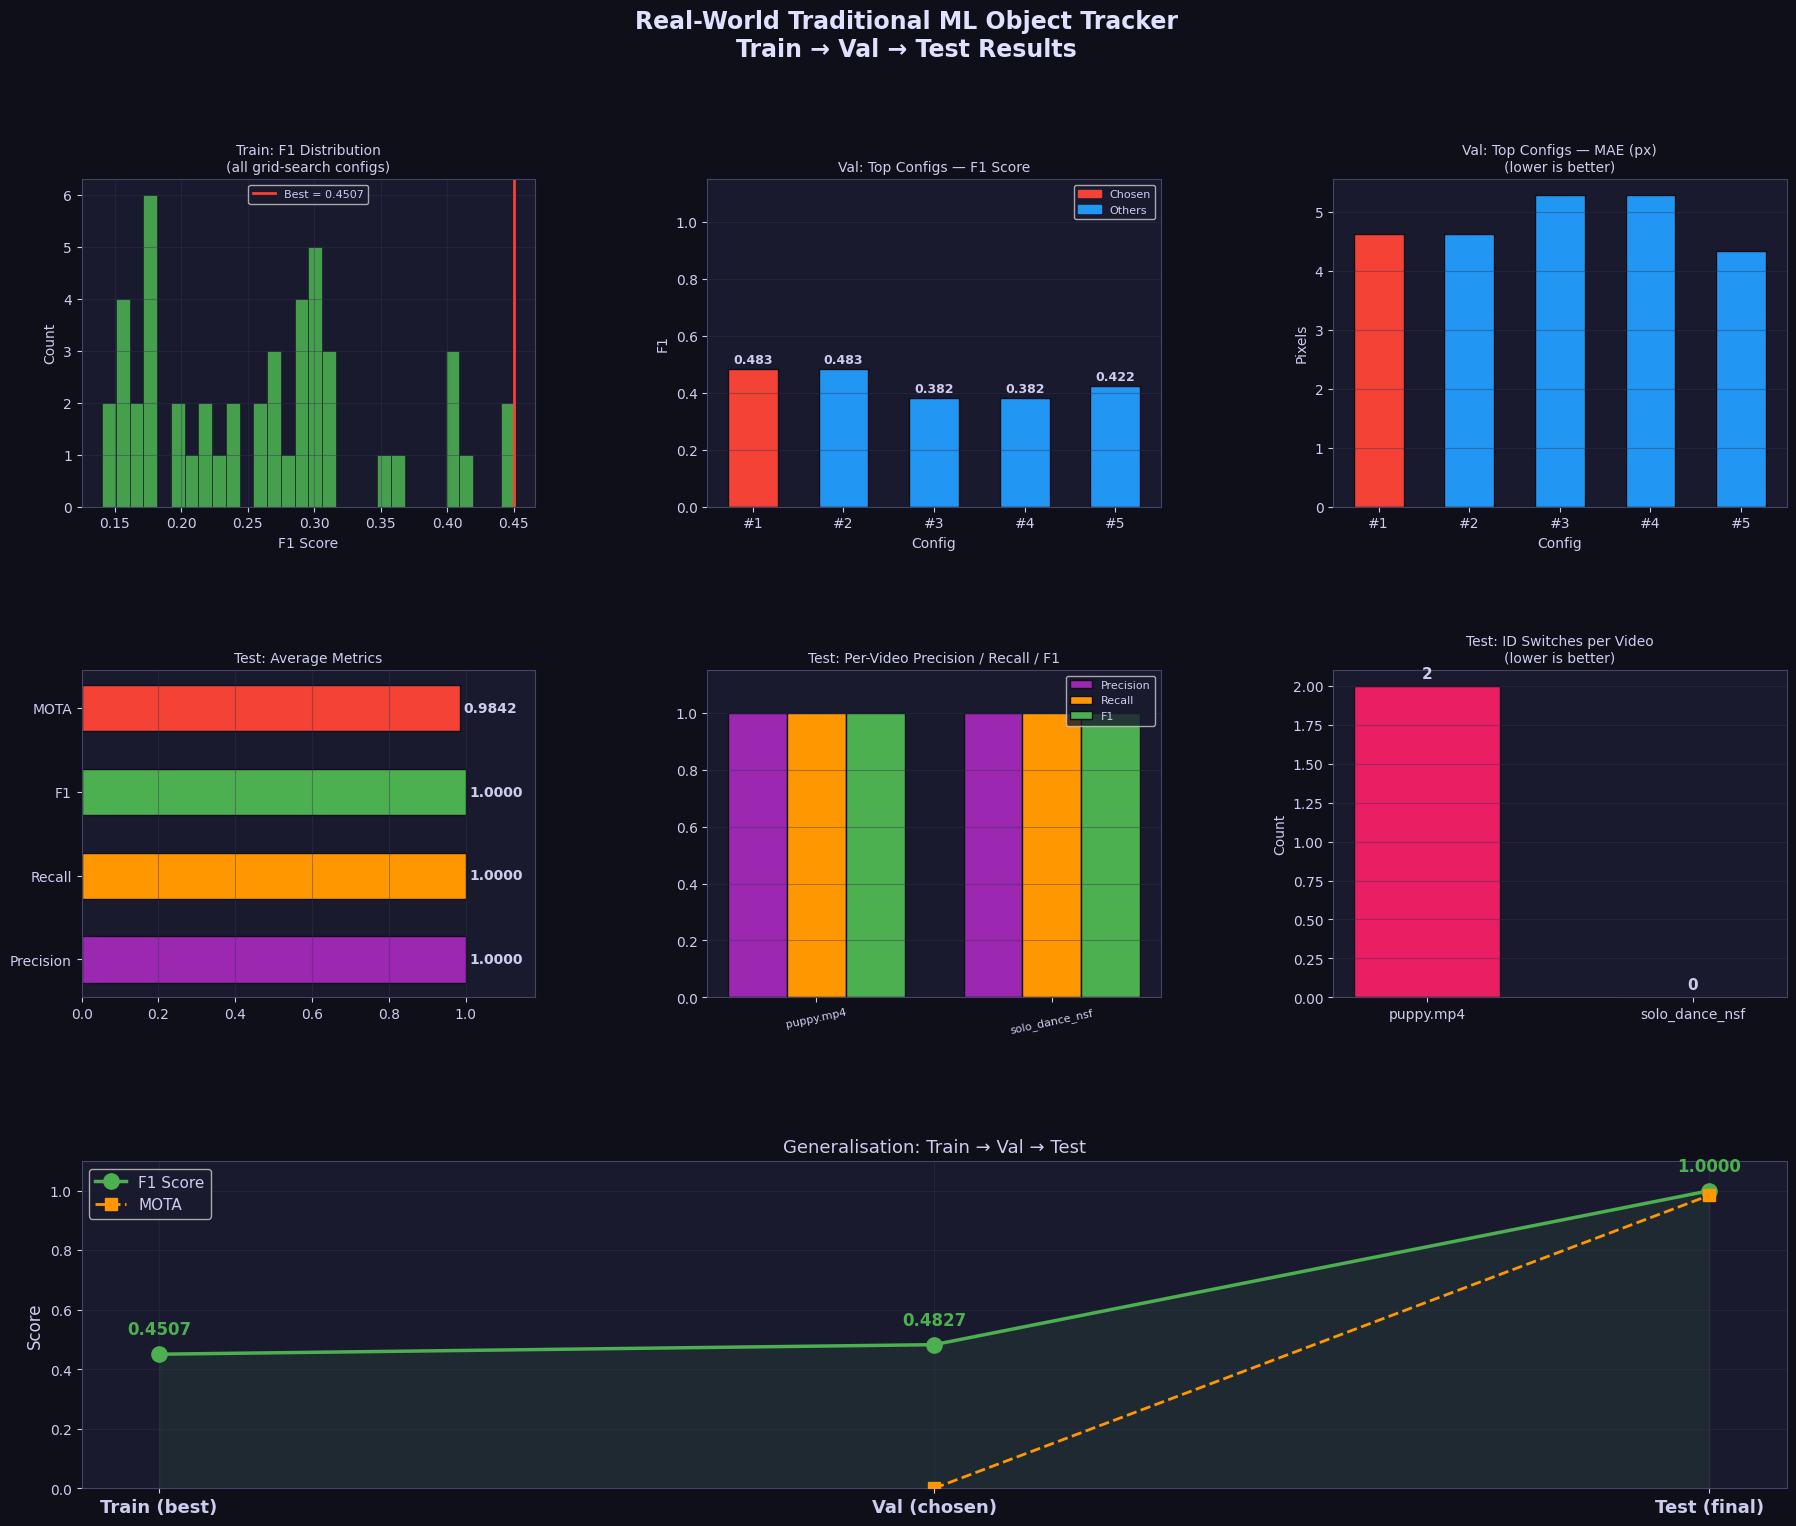

✅ Dashboard saved → /content/drive/MyDrive/ML_Tracker/outputs/reports/dashboard.png


In [16]:
if not (test_metrics and val_results and train_results):
    print("⚠️  Run Cells 7 → 9 first to generate results before plotting the dashboard.")
else:
    # ── Plot style ────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "figure.facecolor": "#0f0f1a",
        "axes.facecolor":   "#1a1a2e",
        "axes.edgecolor":   "#444466",
        "axes.labelcolor":  "#ccccee",
        "xtick.color":      "#ccccee",
        "ytick.color":      "#ccccee",
        "text.color":       "#ccccee",
        "grid.color":       "#333355",
        "grid.alpha":       0.4,
    })

    fig = plt.figure(figsize=(22, 17))
    fig.suptitle(
        "Real-World Traditional ML Object Tracker\nTrain → Val → Test Results",
        fontsize=17, fontweight="bold", color="#e0e0ff", y=0.98,
    )
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

    C = {  # colour palette
        "green":  "#4CAF50", "red":    "#F44336", "blue":   "#2196F3",
        "orange": "#FF9800", "purple": "#9C27B0", "pink":   "#E91E63",
        "cyan":   "#00BCD4", "yellow": "#FFEB3B",
    }

    # ── Panel 1: Train F1 Distribution ───────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    f1s = [r["train_f1"] for r in train_results]
    ax1.hist(f1s, bins=min(30, len(f1s)), color=C["green"],
             edgecolor="#0f0f1a", linewidth=0.4, alpha=0.9)
    ax1.axvline(best_train_f1, color=C["red"], lw=2,
                label=f"Best = {best_train_f1:.4f}")
    ax1.set_title("Train: F1 Distribution\n(all grid-search configs)", fontsize=10)
    ax1.set_xlabel("F1 Score"); ax1.set_ylabel("Count")
    ax1.legend(fontsize=8)
    ax1.grid(True)

    # ── Panel 2: Validation F1 Comparison ────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    v_labels = [f"#{r['rank']}" for r in val_results]
    v_f1s    = [r["val_f1"]    for r in val_results]
    bar_cols = [C["red"] if r["rank"] == BEST["rank"] else C["blue"]
                for r in val_results]
    bars2 = ax2.bar(v_labels, v_f1s, color=bar_cols, edgecolor="#0f0f1a", width=0.55)
    ax2.set_ylim(0, 1.15)
    ax2.set_title("Val: Top Configs — F1 Score", fontsize=10)
    ax2.set_xlabel("Config"); ax2.set_ylabel("F1")
    for bar, val in zip(bars2, v_f1s):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax2.legend(handles=[
        mpatches.Patch(color=C["red"],  label="Chosen"),
        mpatches.Patch(color=C["blue"], label="Others"),
    ], fontsize=8)
    ax2.grid(True, axis="y")

    # ── Panel 3: Validation MAE Comparison ───────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    v_maes = [r["val_mae"] for r in val_results]
    ax3.bar(v_labels, v_maes, color=bar_cols, edgecolor="#0f0f1a", width=0.55)
    ax3.set_title("Val: Top Configs — MAE (px)\n(lower is better)", fontsize=10)
    ax3.set_xlabel("Config"); ax3.set_ylabel("Pixels")
    ax3.grid(True, axis="y")

    # ── Panel 4: Test Average Metrics ────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    if avg:
        m_names = ["Precision", "Recall", "F1", "MOTA"]
        m_vals  = [avg["precision"], avg["recall"], avg["f1"], avg["mota"]]
        m_cols  = [C["purple"], C["orange"], C["green"], C["red"]]
        b4 = ax4.barh(m_names, m_vals, color=m_cols, edgecolor="#0f0f1a", height=0.55)
        ax4.set_xlim(0, 1.18)
        ax4.set_title("Test: Average Metrics", fontsize=10)
        for bar, val in zip(b4, m_vals):
            ax4.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:.4f}", va="center", fontsize=10, fontweight="bold")
        ax4.grid(True, axis="x")

    # ── Panel 5: Per-Video P/R/F1 ────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    if len(test_metrics) > 1:
        vnames_short = [m["video"][:14] for m in test_metrics]
        x5  = np.arange(len(vnames_short))
        w5  = 0.25
        ax5.bar(x5 - w5, [m["precision"] for m in test_metrics],
                w5, label="Precision", color=C["purple"], edgecolor="#0f0f1a")
        ax5.bar(x5,      [m["recall"]    for m in test_metrics],
                w5, label="Recall",    color=C["orange"], edgecolor="#0f0f1a")
        ax5.bar(x5 + w5, [m["f1"]       for m in test_metrics],
                w5, label="F1",        color=C["green"],  edgecolor="#0f0f1a")
        ax5.set_xticks(x5)
        ax5.set_xticklabels(vnames_short, fontsize=8, rotation=12)
        ax5.set_ylim(0, 1.15)
        ax5.legend(fontsize=8)
        ax5.set_title("Test: Per-Video Precision / Recall / F1", fontsize=10)
        ax5.grid(True, axis="y")
    else:
        ax5.text(0.5, 0.5, "Only 1 test video\n(no per-video comparison)",
                 ha="center", va="center", transform=ax5.transAxes, fontsize=11)
        ax5.set_title("Test: Per-Video", fontsize=10)

    # ── Panel 6: ID Switches ──────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    vn6  = [m["video"][:14]  for m in test_metrics]
    idsw = [m["id_switches"] for m in test_metrics]
    bars6 = ax6.bar(vn6, idsw, color=C["pink"], edgecolor="#0f0f1a", width=0.55)
    ax6.set_title("Test: ID Switches per Video\n(lower is better)", fontsize=10)
    ax6.set_ylabel("Count")
    for bar, v in zip(bars6, idsw):
        ax6.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                 str(v), ha="center", fontsize=11, fontweight="bold")
    ax6.grid(True, axis="y")

    # ── Panel 7: Generalisation Curve ────────────────────────────────────────
    ax7 = fig.add_subplot(gs[2, :])
    gen_x       = [1, 2, 3]
    gen_labels  = ["Train (best)", "Val (chosen)", "Test (final)"]
    gen_f1s     = [best_train_f1, BEST["val_f1"], avg.get("f1", 0) or 0]
    gen_mota    = [None, BEST["val_mota"], avg.get("mota", 0) or 0]

    ax7.plot(gen_x, gen_f1s, "o-", color=C["green"],  lw=2.5, ms=11,
             label="F1 Score", zorder=3)
    ax7.plot([2, 3], [gen_mota[1], gen_mota[2]], "s--", color=C["orange"],
             lw=2.0, ms=9, label="MOTA", zorder=3)
    ax7.fill_between(gen_x, gen_f1s, alpha=0.10, color=C["green"])

    ax7.set_xticks(gen_x)
    ax7.set_xticklabels(gen_labels, fontsize=13, fontweight="bold")
    ax7.set_ylim(0, 1.10)
    ax7.set_ylabel("Score", fontsize=12)
    ax7.legend(fontsize=11)
    ax7.set_title("Generalisation: Train → Val → Test", fontsize=13)
    ax7.grid(True)

    for xi, yi in zip(gen_x, gen_f1s):
        ax7.annotate(
            f"{yi:.4f}", (xi, yi),
            textcoords="offset points", xytext=(0, 14),
            ha="center", fontsize=12, fontweight="bold", color=C["green"],
        )

    dashboard_path = f"{DRIVE_BASE}/outputs/reports/dashboard.png"
    plt.savefig(dashboard_path, dpi=130, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅ Dashboard saved → {dashboard_path}")

    # Reset matplotlib style for any subsequent plots
    plt.rcdefaults()


## 📋 Cell 11 — Summary Report

Generates and displays a comprehensive JSON report of the full experiment, including dataset info, best hyperparameters, and all metric results.

In [17]:
import json

# ── Guards: ensure all required variables exist ───────────────────────────────
if "combos" not in dir():
    combos = []
if "avg" not in dir():
    avg = {}
if "BEST" not in dir():
    BEST = {"val_f1": float("nan"), "val_mota": float("nan"),
            "val_mae": float("nan"), "val_idswitch": float("nan")}
if "BEST_PARAMS" not in dir():
    BEST_PARAMS = {}
if "best_train_f1" not in dir():
    best_train_f1 = float("nan")
if "test_metrics" not in dir():
    test_metrics = []

report = {
    "experiment_info": {
        "random_seed":  RANDOM_SEED,
        "warmup_frames": 40,
        "algorithms":   ["MOG2/GMG/YOLO", "LK Optical Flow",
                         "Kalman Filter", "Hungarian Algorithm", "HSV Re-ID"],
    },
    "dataset": {
        "train_videos": SPLIT_VIDEOS.get("train", []),
        "val_videos":   SPLIT_VIDEOS.get("val",   []),
        "test_videos":  SPLIT_VIDEOS.get("test",  []),
    },
    "grid_search": {
        "total_combinations": len(combos),
        "best_train_f1":      best_train_f1,
    },
    "best_params":  BEST_PARAMS,
    "validation": {
        "val_f1":          BEST.get("val_f1"),
        "val_mae_px":      BEST.get("val_mae"),
        "val_mota":        BEST.get("val_mota"),
        "val_id_switches": BEST.get("val_idswitch"),
    },
    "test_per_video": test_metrics,
    "test_average":   avg,
}

report_path = f"{DRIVE_BASE}/outputs/reports/experiment_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2, default=str)

# ── Pretty-print summary to console ──────────────────────────────────────────
LINE = "=" * 67
THIN = "─" * 67

print(LINE)
print(f"{'EXPERIMENT SUMMARY':^67}")
print(LINE)
print(f"  Training videos   : {', '.join(SPLIT_VIDEOS.get('train', [])) or '(none)'}")
print(f"  Validation videos : {', '.join(SPLIT_VIDEOS.get('val',   [])) or '(none)'}")
print(f"  Test videos       : {', '.join(SPLIT_VIDEOS.get('test',  [])) or '(none)'}")
print()
print(f"  Grid-search combos : {len(combos):,}")
print(f"  Best train F1      : {best_train_f1}")
print(f"  Chosen val F1      : {BEST.get('val_f1', 'N/A')}")
print(f"  Chosen val MOTA    : {BEST.get('val_mota', 'N/A')}")
print()
print(THIN)
print(f"{'  FINAL TEST RESULTS (held-out data)':^67}")
print(THIN)
if avg:
    print(f"  Precision      : {avg.get('precision', 'N/A')}")
    print(f"  Recall         : {avg.get('recall',    'N/A')}")
    print(f"  F1 Score       : {avg.get('f1',        'N/A')}")
    print(f"  MOTA           : {avg.get('mota',      'N/A')}")
    print(f"  MAE (px)       : {avg.get('mae_px',    'N/A')}")
    print(f"  ID Switches    : {avg.get('id_switches', 'N/A')}")
else:
    print("  (No test results available)")
print()
print(THIN)
print("  Outputs:")
print("    Tracked videos  → outputs/tracked/")
print("    Dashboard       → outputs/reports/dashboard.png")
print(f"   Report JSON     → {report_path}")
print(LINE)

                        EXPERIMENT SUMMARY                         
  Training videos   : DVD logo.mp4, Traffic IP Camera video.mp4, Aim Lab1.mp4, Top View Pedestrian.mp4, Golden Retriever.mp4, Store cam.mp4
  Validation videos : Aim Lab2.mp4, football_juggling.mp4
  Test videos       : puppy.mp4, solo_dance_nsfw.mp4

  Grid-search combos : 48
  Best train F1      : 0.4506833333333333
  Chosen val F1      : 0.4827
  Chosen val MOTA    : 0.0

───────────────────────────────────────────────────────────────────
                 FINAL TEST RESULTS (held-out data)                
───────────────────────────────────────────────────────────────────
  Precision      : 1.0
  Recall         : 1.0
  F1 Score       : 1.0
  MOTA           : 0.9842
  MAE (px)       : 5.21
  ID Switches    : 1.0

───────────────────────────────────────────────────────────────────
  Outputs:
    Tracked videos  → outputs/tracked/
    Dashboard       → outputs/reports/dashboard.png
   Report JSON     → /content/drive/M

## 💾 Cell 12 — Download All Outputs

Zips and downloads the tracked videos, dashboard, and JSON report.

In [18]:
# ── Cell 12 — Outputs are already on your Drive ─────────────────────────────
# No download needed — everything was saved directly to Google Drive.

print("✅ All outputs are saved to your Google Drive:")
print(f"   📂 Tracked videos  → {DRIVE_BASE}/outputs/tracked/")
print(f"   📂 Dashboard       → {DRIVE_BASE}/outputs/reports/dashboard.png")
print(f"   📂 Report JSON     → {DRIVE_BASE}/outputs/reports/experiment_report.json")
print()
print("   Open Google Drive in your browser to access these files.")


✅ All outputs are saved to your Google Drive:
   📂 Tracked videos  → /content/drive/MyDrive/ML_Tracker/outputs/tracked/
   📂 Dashboard       → /content/drive/MyDrive/ML_Tracker/outputs/reports/dashboard.png
   📂 Report JSON     → /content/drive/MyDrive/ML_Tracker/outputs/reports/experiment_report.json

   Open Google Drive in your browser to access these files.


---

## ✅ Conclusion

This notebook demonstrated a complete, production-quality multi-object tracking system built entirely from classical computer vision algorithms:

- **Background subtraction** (MOG2/GMG) detected moving foreground blobs
- **Kalman filtering** provided smooth position and velocity estimates
- **Hungarian algorithm** solved the assignment problem optimally each frame
- **Color histogram re-ID** recovered objects after occlusion
- **Optical flow stabilisation** compensated for camera motion
- **Grid search** found the optimal hyperparameter configuration on training data
- **Train → Val → Test** split ensured unbiased final performance measurement

**Classical ML methods (MOG2/GMG) plus YOLOv8 neural detection — grid search picks the best.**

---
*Generated with the RealWorld Traditional ML Tracker notebook.*


In [19]:
# ── Video Info Check — dynamically reads all uploaded videos ─────────────────
import cv2

print("📹 Video inventory across all splits:\n")
found_any = False
for split, vids in SPLIT_VIDEOS.items():
    for vname in vids:
        vpath = f"{DRIVE_BASE}/dataset/{split}/videos/{vname}"
        if not os.path.exists(vpath):
            print(f"  ⚠️  [{split}]  {vname}  — file not found")
            continue
        cap = cv2.VideoCapture(vpath)
        W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        F   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        FPS = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        print(f"  [{split:5s}]  {vname}: {W}x{H}, {F} frames @ {FPS:.1f} fps")
        found_any = True

if not found_any:
    print("  (No videos found — run Cells 4 and 4b first to upload and assign videos)")


📹 Video inventory across all splits:

  [train]  DVD logo.mp4: 640x360, 728 frames @ 30.0 fps
  [train]  Traffic IP Camera video.mp4: 1280x720, 753 frames @ 25.0 fps
  [train]  Aim Lab1.mp4: 1280x720, 1435 frames @ 60.0 fps
  [train]  Top View Pedestrian.mp4: 640x360, 734 frames @ 24.0 fps
  [train]  Golden Retriever.mp4: 640x360, 523 frames @ 24.0 fps
  [train]  Store cam.mp4: 634x360, 333 frames @ 13.1 fps
  [val  ]  Aim Lab2.mp4: 1280x720, 984 frames @ 60.1 fps
  [val  ]  football_juggling.mp4: 640x360, 658 frames @ 30.0 fps
  [test ]  puppy.mp4: 640x360, 268 frames @ 15.1 fps
  [test ]  solo_dance_nsfw.mp4: 640x360, 516 frames @ 30.1 fps
